# ALDIMI - Uso de Kaggle datasets para análisis EDA

En este notebook se descarga y explora Kaggle datasets con data real(no synthetic).

In [1]:
import pandas as pd
import numpy as np

In [3]:
%pip install kagglehub


  Using cached kagglehub-1.0.1-py3-none-any.whl.metadata (40 kB)
  Using cached kagglesdk-0.1.22-py3-none-any.whl.metadata (13 kB)
Using cached kagglehub-1.0.1-py3-none-any.whl (70 kB)
Using cached kagglesdk-0.1.22-py3-none-any.whl (212 kB)



[notice] A new release of pip is available: 24.2 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:

import os
import glob
import kagglehub
# Descargamos los datasets desde Kaggle
path_risk = kagglehub.dataset_download("tarekmasryo/cancer-risk-factors-dataset")
path_county = kagglehub.dataset_download("thedevastator/county-level-socioeconomic-and-cancer-clinical-t")
# Buscamos los archivos CSV en las carpetas descargadas
risk_csvs = glob.glob(os.path.join(path_risk, "**", "*.csv"), recursive=True)
county_csvs = glob.glob(os.path.join(path_county, "**", "*.csv"), recursive=True)

print("Risk factors CSVs:")
for p in risk_csvs:
    print(" -", p)

print("County-level CSVs:")
for p in county_csvs:
    print(" -", p)

# Cargamos el primer CSV de cada dataset
risk_df = pd.read_csv(risk_csvs[0])
county_df = pd.read_csv(county_csvs[0])

risk_df.head()

c:\Users\ALVARO\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Risk factors CSVs:
 - C:\Users\ALVARO\.cache\kagglehub\datasets\tarekmasryo\cancer-risk-factors-dataset\versions\1\cancer-risk-factors.csv
County-level CSVs:
 - C:\Users\ALVARO\.cache\kagglehub\datasets\thedevastator\county-level-socioeconomic-and-cancer-clinical-t\versions\1\census_county_population.csv
 - C:\Users\ALVARO\.cache\kagglehub\datasets\thedevastator\county-level-socioeconomic-and-cancer-clinical-t\versions\1\cen_income.csv
 - C:\Users\ALVARO\.cache\kagglehub\datasets\thedevastator\county-level-socioeconomic-and-cancer-clinical-t\versions\1\countByZip.csv
 - C:\Users\ALVARO\.cache\kagglehub\datasets\thedevastator\county-level-socioeconomic-and-cancer-clinical-t\versions\1\countyData.csv
 - C:\Users\ALVARO\.cache\kagglehub\datasets\thedevastator\county-level-socioeconomic-and-cancer-clinical-t\versions\1\data_dict.csv
 - C:\Users\ALVARO\.cache\kagglehub\datasets\thedevastator\county-level-socioeconomic-and-cancer-clinical-t\versions\1\death_r.csv
 - C:\Users\ALVARO\.cache\ka

,Patient_ID,Cancer_Type,Age,Gender,Smoking,Alcohol_Use,Obesity,Family_History,Diet_Red_Meat,Diet_Salted_Processed,...,Physical_Activity,Air_Pollution,Occupational_Hazards,BRCA_Mutation,H_Pylori_Infection,Calcium_Intake,Overall_Risk_Score,BMI,Physical_Activity_Level,Risk_Level
0,LU0000,Breast,68,0,7,2,8,0,5,3,...,4,6,3,1,0,0,0.398696,28.0,5,Medium
1,LU0001,Prostate,74,1,8,9,8,0,0,3,...,1,3,3,0,0,5,0.424299,25.4,9,Medium
2,LU0002,Skin,55,1,7,10,7,0,3,3,...,1,8,10,0,0,6,0.605082,28.6,2,Medium
3,LU0003,Colon,61,0,6,2,2,0,6,2,...,6,4,8,0,0,8,0.318449,32.1,7,Low
4,LU0004,Lung,67,1,10,7,4,0,6,3,...,9,10,9,0,0,5,0.524358,25.1,2,Medium


In [ ]:

print("risk_df columns:")
print(risk_df.columns.tolist())
print("\ncounty_df columns:")
print(county_df.columns.tolist())
# Verificar si hay columnas comunes para posible merge 
common = set(risk_df.columns).intersection(county_df.columns)
print("\nCommon columns:", common)
# Identificar posibles columnas de ID para unir datasets
candidates = [c for c in ['Patient_ID','patient_id','PatientId','ID','FIPS','County','CountyFIPS','state','State','county','ST','GEOID'] if c in set(risk_df.columns).union(set(county_df.columns))]
print("Candidate columns to join on (present in either dataset):", candidates)
# Se va a mostrar valores de muestra de las columnas candidatas
for c in candidates:
    print(f"\nSample values for {c} from risk_df:")
    if c in risk_df.columns:
        display(risk_df[c].dropna().unique()[:10])
    else:
        print(" - not in risk_df")
    print(f"Sample values for {c} from county_df:")
    if c in county_df.columns:
        display(county_df[c].dropna().unique()[:10])
    else:
        print(" - not in county_df")

risk_df columns:
['Patient_ID', 'Cancer_Type', 'Age', 'Gender', 'Smoking', 'Alcohol_Use', 'Obesity', 'Family_History', 'Diet_Red_Meat', 'Diet_Salted_Processed', 'Fruit_Veg_Intake', 'Physical_Activity', 'Air_Pollution', 'Occupational_Hazards', 'BRCA_Mutation', 'H_Pylori_Infection', 'Calcium_Intake', 'Overall_Risk_Score', 'BMI', 'Physical_Activity_Level', 'Risk_Level']

county_df columns:
['index', 'SUMLEV', 'REGION', 'DIVISION', 'STATE', 'COUNTY', 'STNAME', 'CTYNAME', 'CENSUS2010POP', 'ESTIMATESBASE2010', 'POPESTIMATE2010', 'POPESTIMATE2011', 'POPESTIMATE2012', 'POPESTIMATE2013', 'POPESTIMATE2014', 'POPESTIMATE2015', 'NPOPCHG_2010', 'NPOPCHG_2011', 'NPOPCHG_2012', 'NPOPCHG_2013', 'NPOPCHG_2014', 'NPOPCHG_2015', 'BIRTHS2010', 'BIRTHS2011', 'BIRTHS2012', 'BIRTHS2013', 'BIRTHS2014', 'BIRTHS2015', 'DEATHS2010', 'DEATHS2011', 'DEATHS2012', 'DEATHS2013', 'DEATHS2014', 'DEATHS2015', 'NATURALINC2010', 'NATURALINC2011', 'NATURALINC2012', 'NATURALINC2013', 'NATURALINC2014', 'NATURALINC2015', 'INT

array(['LU0000', 'LU0001', 'LU0002', 'LU0003', 'LU0004', 'LU0005',
       'LU0006', 'LU0007', 'LU0008', 'LU0009'], dtype=object)

Sample values for Patient_ID from county_df:
 - not in county_df


In [5]:
num_pacientes = risk_df['Patient_ID'].nunique()
print(f"Número de pacientes únicos: {num_pacientes}")

Número de pacientes únicos: 2000


In [6]:
#Para ver estructura y primeras impresiones de los datos
print("\n=== Muestra aleatoria de 10 registros")
print(risk_df.sample(10))


=== Muestra aleatoria de 10 registros
     Patient_ID Cancer_Type  Age  Gender  Smoking  Alcohol_Use  Obesity  \
1219     PR0019      Breast   58       0        6            1       10   
429      BR0029        Lung   64       0       10            9       10   
1639     ST0039    Prostate   72       1        0            6        9   
1316     PR0116       Colon   71       1        4            2        4   
320      LU0320       Colon   61       0       10           10        1   
1233     PR0033        Lung   65       1        9            1       10   
1742     ST0142        Skin   48       0        4            1        7   
513      BR0113    Prostate   59       1        2            7        2   
1570     PR0370       Colon   64       1        2            5        2   
1248     PR0048    Prostate   75       1        5            2        7   

      Family_History  Diet_Red_Meat  Diet_Salted_Processed  ...  \
1219               0              5                      1  ...   
4

In [7]:
print(risk_df.select_dtypes(include=['int64', 'float64']).columns.tolist())
print(county_df.select_dtypes(include=['int64', 'float64']).columns.tolist())

['Age', 'Gender', 'Smoking', 'Alcohol_Use', 'Obesity', 'Family_History', 'Diet_Red_Meat', 'Diet_Salted_Processed', 'Fruit_Veg_Intake', 'Physical_Activity', 'Air_Pollution', 'Occupational_Hazards', 'BRCA_Mutation', 'H_Pylori_Infection', 'Calcium_Intake', 'Overall_Risk_Score', 'BMI', 'Physical_Activity_Level']
['index', 'SUMLEV', 'REGION', 'DIVISION', 'STATE', 'COUNTY', 'CENSUS2010POP', 'ESTIMATESBASE2010', 'POPESTIMATE2010', 'POPESTIMATE2011', 'POPESTIMATE2012', 'POPESTIMATE2013', 'POPESTIMATE2014', 'POPESTIMATE2015', 'NPOPCHG_2010', 'NPOPCHG_2011', 'NPOPCHG_2012', 'NPOPCHG_2013', 'NPOPCHG_2014', 'NPOPCHG_2015', 'BIRTHS2010', 'BIRTHS2011', 'BIRTHS2012', 'BIRTHS2013', 'BIRTHS2014', 'BIRTHS2015', 'DEATHS2010', 'DEATHS2011', 'DEATHS2012', 'DEATHS2013', 'DEATHS2014', 'DEATHS2015', 'NATURALINC2010', 'NATURALINC2011', 'NATURALINC2012', 'NATURALINC2013', 'NATURALINC2014', 'NATURALINC2015', 'INTERNATIONALMIG2010', 'INTERNATIONALMIG2011', 'INTERNATIONALMIG2012', 'INTERNATIONALMIG2013', 'INTERNAT

In [8]:
print(risk_df.select_dtypes(include=['object']).columns.tolist())
print(county_df.select_dtypes(include=['object']).columns.tolist())

['Patient_ID', 'Cancer_Type', 'Risk_Level']
['STNAME', 'CTYNAME']


In [9]:
#Identificar casos extremos, correlaciones, outliers potenciales
high_risk_old = risk_df[(risk_df['Risk_Level'] == 'High') & (risk_df['Age'] > 60)]
print(f"\n=== Pacientes Alto Riesgo + Edad > 60: {len(high_risk_old)}")
print(high_risk_old[['Patient_ID', 'Age', 'Risk_Level', 'Overall_Risk_Score']].head(10))


=== Pacientes Alto Riesgo + Edad > 60: 67
    Patient_ID  Age Risk_Level  Overall_Risk_Score
24      LU0024   75       High            0.669148
38      LU0038   85       High            0.688493
65      LU0065   65       High            0.662771
74      LU0074   67       High            0.725770
96      LU0096   63       High            0.663253
152     LU0152   78       High            0.713635
159     LU0159   71       High            0.667530
170     LU0170   63       High            0.681933
172     LU0172   66       High            0.670469
181     LU0181   62       High            0.688962


In [10]:
# Pacientes con BMI extremo (obesidad severa) - ayuda a dar un primer vistazo de la calidad de los datos
obese_patients = risk_df[risk_df['BMI'] > 35]
print(f"\n=== Pacientes con BMI > 35: {len(obese_patients)}")
print(obese_patients[['Patient_ID', 'BMI', 'Overall_Risk_Score']].head())


=== Pacientes con BMI > 35: 25
    Patient_ID   BMI  Overall_Risk_Score
113     LU0113  35.9            0.477236
179     LU0179  36.9            0.485187
209     LU0209  41.4            0.387479
220     LU0220  35.3            0.664544
478     BR0078  38.3            0.382078


In [11]:
# Pacientes con historial familiar y BRCA mutation - ayuda a dar un primer vistazo de la calidad de los datos
genetic_risk = risk_df[(risk_df['Family_History'] == 1) | (risk_df['BRCA_Mutation'] == 1)]
print(f"\nPacientes con riesgo genético: {len(genetic_risk)}")


Pacientes con riesgo genético: 440


In [12]:
# Primeros 10 pacientes, solo columnas relevantes
subset = risk_df.iloc[:10, [1, 2, 4, 5, 9, 20]] 
print("\n Primeros 10 pacientes (columnas clave)")
print(subset)


 Primeros 10 pacientes (columnas clave)
  Cancer_Type  Age  Smoking  Alcohol_Use  Diet_Salted_Processed Risk_Level
0      Breast   68        7            2                      3     Medium
1    Prostate   74        8            9                      3     Medium
2        Skin   55        7           10                      3     Medium
3       Colon   61        6            2                      2        Low
4        Lung   67       10            7                      3     Medium
5        Lung   77       10            8                      0     Medium
6        Lung   59       10           10                      4       High
7    Prostate   74        8            6                      3     Medium
8       Colon   71        9            0                      4     Medium
9        Skin   55        7            1                      4     Medium


In [13]:
# Pacientes con alto consumo de riesgo - ayuda a dar un primer vistazo de la calidad de los datos
high_risk_behaviors = risk_df.query("Smoking > 7 and Alcohol_Use > 7 and Diet_Salted_Processed > 7")
print(f"\n Pacientes con altos factores de riesgo conductual: {len(high_risk_behaviors)} ")


 Pacientes con altos factores de riesgo conductual: 44 


In [14]:
# Riesgo promedio por tipo de cáncer
cancer_risk = risk_df.groupby('Cancer_Type')['Overall_Risk_Score'].agg(['mean', 'std', 'count'])
print("\n Riesgo promedio por tipo de cáncer ")
print(cancer_risk.sort_values('mean', ascending=False))


 Riesgo promedio por tipo de cáncer 
                 mean       std  count
Cancer_Type                           
Lung         0.499914  0.117148    527
Colon        0.466093  0.122238    418
Skin         0.456224  0.117832    290
Breast       0.434099  0.115732    460
Prostate     0.388936  0.115035    305


In [ ]:
#que se inserte en el directorio actual
output_dir = "."
#Crearemos 3000 pacientes (upsampling si es necesario), se mantiene caracteristicas clave del condado y se guarda el CSV fusionado
target_n = 3000
# Upsample risk_df to target_n
if len(risk_df) >= target_n:
    patient_df = risk_df.sample(n=target_n, replace=False, random_state=42).reset_index(drop=True)
else:
    patient_df = risk_df.sample(n=target_n, replace=True, random_state=42).reset_index(drop=True)

# Asignamos nuevos IDs numéricos (1001, 1002, ...)
start_id = 1001
patient_df = patient_df.reset_index(drop=True)
patient_df['Patient_ID'] = [start_id + i for i in range(len(patient_df))]

# Se elije las columnas del condado a mantener
keep_cols = [c for c in ['STATE','COUNTY','STNAME','CTYNAME','POPESTIMATE2015','CENSUS2010POP'] if c in county_df.columns]
if not keep_cols:
    # fallback: se toma las primeras 5 columnas de county_df
    keep_cols = county_df.columns.tolist()[:5]

# Usar población como peso para muestreo (más población = más probabilidad)
pop_col = 'POPESTIMATE2015' if 'POPESTIMATE2015' in county_df.columns else ('CENSUS2010POP' if 'CENSUS2010POP' in county_df.columns else None)
if pop_col is None:
    county_df['__pop_dummy'] = 1.0
    pop_col = '__pop_dummy'

county_df[pop_col] = county_df[pop_col].fillna(1).astype(float).clip(lower=0.0)

# Muestrear condados con reemplazo, ponderado por población y así lograr coincidir con el nro. de pacientes
sampled_counties = county_df[keep_cols].sample(n=len(patient_df), replace=True, weights=county_df[pop_col], random_state=42).reset_index(drop=True)

# Usamos prefijo en las columnas de condado y evitar "colisiones"
county_pref = sampled_counties.add_prefix('county_')
merged_df = pd.concat([patient_df.reset_index(drop=True), county_pref.reset_index(drop=True)], axis=1)

# Guardamos CSV fusionado
output_path = os.path.join(output_dir, "Dataset_ALDIMI_Merged.csv")
merged_df.to_csv(output_path, index=False)
print("Merged CSV saved to:", output_path)
merged_df.shape

Merged CSV saved to: C:\Users\Daniel\Documents\UPC\machine learning\dataset\Dataset_ALDIMI_Merged.csv


(3000, 27)

In [ ]:
# Primer vistazo al dataset fusionado
import os
merged_path = os.path.join(output_dir, "Dataset_ALDIMI_Merged.csv")
merged_check = pd.read_csv(merged_path)
print('merged shape:', merged_check.shape)
merged_check.head()

merged shape: (3000, 27)


,Patient_ID,Cancer_Type,Age,Gender,Smoking,Alcohol_Use,Obesity,Family_History,Diet_Red_Meat,Diet_Salted_Processed,...,Overall_Risk_Score,BMI,Physical_Activity_Level,Risk_Level,county_STATE,county_COUNTY,county_STNAME,county_CTYNAME,county_POPESTIMATE2015,county_CENSUS2010POP
0,1001,Lung,52,0,10,7,4,0,10,3,...,0.601460,27.2,0,Medium,19,103,Iowa,Johnson County,144251.0,130882
1,1002,Colon,73,1,5,4,8,0,7,4,...,0.380986,28.7,8,Medium,51,760,Virginia,Richmond city,220289.0,204214
2,1003,Skin,70,0,3,0,2,0,4,1,...,0.265377,26.8,1,Low,40,109,Oklahoma,Oklahoma County,776864.0,718633
3,1004,Skin,64,1,6,3,4,0,4,3,...,0.397763,26.3,0,Medium,36,0,New York,New York,19795791.0,19378102
4,1005,Skin,60,1,4,8,4,1,1,4,...,0.484590,27.3,2,Medium,6,73,California,San Diego County,3299521.0,3095313


In [ ]:
# Limpiar CSV fus., generar los plots y reportes para el EDA, y creamos los train/test CSV's
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style='whitegrid')
import json

merged_path = os.path.join(output_dir, "Dataset_ALDIMI_Merged.csv")
df_merged = pd.read_csv(merged_path)
print('Loaded merged:', df_merged.shape)

# Identificar columnas de paciente (no empiezan con 'county_')
patient_cols = [c for c in df_merged.columns if not c.startswith('county_')]
# Mantener columnas específicas del condado
desired_county = ['county_STATE','county_CTYNAME','county_POPESTIMATE2015']
county_keep = [c for c in desired_county if c in df_merged.columns]
print('Keeping county columns:', county_keep)

# Creamos dataset limpio (solo pacientes porque county_keep está vacío)
cleaned = df_merged[patient_cols + county_keep].copy()
cleaned_path = os.path.join(output_dir, 'Dataset_ALDIMI_Merged_Clean.csv')
cleaned.to_csv(cleaned_path, index=False)
print('Saved cleaned CSV:', cleaned_path)

# Mapa de calor de correlaciones (solo variables numéricas)- EDA
numeric = cleaned.select_dtypes(include='number')
if not numeric.empty:
    corr = numeric.corr()
    plt.figure(figsize=(8, 6))
    sns.heatmap(corr, annot=True, cmap='Blues', vmin=-1, vmax=1)
    plt.title('Correlation (numeric features)')
    corr_img = os.path.join(output_dir, 'eda_corr_heatmap.png')
    plt.tight_layout()
    plt.savefig(corr_img, dpi=150)
    plt.close()
    print('Saved correlation heatmap:', corr_img)
else:
    corr_img = None
    print('No numeric columns for correlation')

# La distribución numérica -hast 4 columnas
num_cols = numeric.columns.tolist()[:4]
if num_cols:
    ax = cleaned[num_cols].hist(bins=20, figsize=(4*len(num_cols), 4))
    dist_img = os.path.join(output_dir, 'eda_numeric_dists.png')
    plt.suptitle('Numeric distributions')
    plt.savefig(dist_img, dpi=150)
    plt.close()
    print('Saved numeric distributions:', dist_img)
else:
    dist_img = None
    print('No numeric columns for distributions')

# Recuento de categorías principales
cat_cols = cleaned.select_dtypes(include=['object','category']).columns.tolist()
if cat_cols:
    cat = cat_cols[0]
    plt.figure(figsize=(8, 4))
    cleaned[cat].value_counts().head(15).plot(kind='bar')
    plt.title(f'Top categories - {cat}')
    plt.xticks(rotation=30)
    cat_img = os.path.join(output_dir, 'eda_top_categories.png')
    plt.tight_layout()
    plt.savefig(cat_img, dpi=150)
    plt.close()
    print('Saved top categories:', cat_img)
else:
    cat_img = None
    print('No categorical columns for counts')

# Guardamos reporte en .txt con estadísticas
report_path = os.path.join(output_dir, 'ALDIMI_EDA_Report.txt')
with open(report_path, 'w', encoding='utf-8') as f:
    f.write('ALDIMI EDA Report\n')
    f.write('Merged shape: %s\n' % (str(df_merged.shape)))
    f.write('Cleaned shape: %s\n' % (str(cleaned.shape)))
    f.write('\nMissing values (per column):\n')
    f.write(str(cleaned.isna().sum()))
    f.write('\n\nNumeric description:\n')
    f.write(str(numeric.describe()))
    if 'corr' in locals():
        f.write('\n\nTop absolute correlations:\n')
        corr_vals = corr.abs().unstack().sort_values(ascending=False).drop_duplicates()
        # skip self-correlation at top
        top_corr = corr_vals[corr_vals < 1].dropna().head(10)
        f.write(str(top_corr))
print('Saved report:', report_path)

# Train/test split (80/20) sin sklearn
train = cleaned.sample(frac=0.8, random_state=42)
test = cleaned.drop(train.index)
train_path = os.path.join(output_dir, 'train.csv')
test_path = os.path.join(output_dir, 'test.csv')
train.to_csv(train_path, index=False)
test.to_csv(test_path, index=False)
print('Saved train/test:', train_path, test_path)

# Resumen de dict
summary = {'cleaned_csv': cleaned_path,'corr_img': corr_img,'dist_img': dist_img,'cat_img': cat_img,'report': report_path,'train_csv': train_path,'test_csv': test_path}
print(json.dumps(summary, indent=2))

Loaded merged: (3000, 27)
Keeping county columns: ['county_STATE', 'county_CTYNAME', 'county_POPESTIMATE2015']
Saved cleaned CSV: C:\Users\Daniel\Documents\UPC\machine learning\dataset\Dataset_ALDIMI_Merged_Clean.csv
Saved correlation heatmap: C:\Users\Daniel\Documents\UPC\machine learning\dataset\eda_corr_heatmap.png
Saved numeric distributions: C:\Users\Daniel\Documents\UPC\machine learning\dataset\eda_numeric_dists.png
Saved top categories: C:\Users\Daniel\Documents\UPC\machine learning\dataset\eda_top_categories.png
Saved report: C:\Users\Daniel\Documents\UPC\machine learning\dataset\ALDIMI_EDA_Report.txt
Saved train/test: C:\Users\Daniel\Documents\UPC\machine learning\dataset\train.csv C:\Users\Daniel\Documents\UPC\machine learning\dataset\test.csv
{
  "cleaned_csv": "C:\\Users\\Daniel\\Documents\\UPC\\machine learning\\dataset\\Dataset_ALDIMI_Merged_Clean.csv",
  "corr_img": "C:\\Users\\Daniel\\Documents\\UPC\\machine learning\\dataset\\eda_corr_heatmap.png",
  "dist_img": "C:\\U

In [ ]:

def show_stats(df, name):
    print(f"=== {name} describe ===")
    display(df.describe(include="all"))  # Se mantienen variables categóricas
# Mostrar estadísticas de risk_df y county_df
for name in ("risk_df", "county_df"):
    if name in globals():
        show_stats(globals()[name], name)

=== risk_df describe ===


,Patient_ID,Cancer_Type,Age,Gender,Smoking,Alcohol_Use,Obesity,Family_History,Diet_Red_Meat,Diet_Salted_Processed,...,Physical_Activity,Air_Pollution,Occupational_Hazards,BRCA_Mutation,H_Pylori_Infection,Calcium_Intake,Overall_Risk_Score,BMI,Physical_Activity_Level,Risk_Level
count,2000,2000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,...,2000.000000,2000.000000,2000.000000,2000.000000,2000.00000,2000.00000,2000.000000,2000.000000,2000.000000,2000
unique,2000,5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3
top,ST0383,Lung,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Medium
freq,1,527,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1574
mean,NaN,NaN,63.248000,0.489000,5.157000,5.035000,5.967500,0.194500,5.189500,4.563500,...,4.015000,5.323000,4.979000,0.032500,0.19650,3.94050,0.454449,26.183350,4.938500,NaN
std,NaN,NaN,10.462946,0.500004,3.325339,3.260996,3.061393,0.395914,3.154452,3.088323,...,2.978458,3.207462,3.212899,0.177368,0.39745,3.04887,0.123074,3.947459,3.166027,NaN
min,NaN,NaN,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.00000,0.00000,0.029285,15.000000,0.000000,NaN
25%,NaN,NaN,56.000000,0.000000,2.000000,2.000000,4.000000,0.000000,3.000000,2.000000,...,1.000000,3.000000,2.000000,0.000000,0.00000,1.00000,0.366982,23.500000,2.000000,NaN
50%,NaN,NaN,64.000000,0.000000,5.000000,5.000000,6.000000,0.000000,5.000000,4.000000,...,4.000000,5.000000,5.000000,0.000000,0.00000,4.00000,0.455399,26.200000,5.000000,NaN
75%,NaN,NaN,70.000000,1.000000,8.000000,8.000000,9.000000,0.000000,8.000000,7.000000,...,6.000000,8.000000,8.000000,0.000000,0.00000,6.00000,0.539782,28.700000,8.000000,NaN


=== county_df describe ===


,index,SUMLEV,REGION,DIVISION,STATE,COUNTY,STNAME,CTYNAME,CENSUS2010POP,ESTIMATESBASE2010,...,RDOMESTICMIG2011,RDOMESTICMIG2012,RDOMESTICMIG2013,RDOMESTICMIG2014,RDOMESTICMIG2015,RNETMIG2011,RNETMIG2012,RNETMIG2013,RNETMIG2014,RNETMIG2015
count,3193.000000,3193.000000,3193.000000,3193.000000,3193.000000,3193.000000,3193,3193,3.193000e+03,3.193000e+03,...,3193.000000,3193.000000,3193.000000,3193.000000,3193.000000,3193.000000,3193.000000,3193.000000,3193.000000,3193.000000
unique,NaN,NaN,NaN,NaN,NaN,NaN,51,1927,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,NaN,NaN,NaN,NaN,NaN,Texas,Washington County,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,NaN,NaN,NaN,NaN,NaN,255,30,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,1596.000000,49.840276,2.668650,5.191356,30.259004,101.918572,NaN,NaN,1.933871e+05,1.933969e+05,...,-1.639167,-2.528381,-1.288083,-2.271925,-1.362607,-0.655205,-1.445775,-0.200419,-1.038960,-0.096759
std,921.884031,1.253884,0.807513,1.973991,15.153897,107.626583,NaN,NaN,1.176201e+06,1.176244e+06,...,10.407267,11.871798,12.186844,11.440505,12.301558,10.613259,12.228155,12.200064,11.471743,12.265772
min,0.000000,40.000000,1.000000,1.000000,1.000000,0.000000,NaN,NaN,8.200000e+01,8.200000e+01,...,-128.205128,-147.727273,-109.876862,-178.947368,-84.844838,-128.205128,-147.727273,-102.988031,-178.947368,-62.322703
25%,798.000000,50.000000,2.000000,4.000000,18.000000,33.000000,NaN,NaN,1.129900e+04,1.129900e+04,...,-6.153101,-7.561799,-6.323058,-7.357497,-6.696825,-5.354221,-6.851764,-5.426357,-6.221820,-5.553088
50%,1596.000000,50.000000,3.000000,5.000000,29.000000,77.000000,NaN,NaN,2.642400e+04,2.644600e+04,...,-1.544618,-2.549859,-1.771445,-1.988101,-2.026566,-0.626174,-1.537988,-0.788296,-0.911948,-0.872527
75%,2394.000000,50.000000,3.000000,7.000000,45.000000,133.000000,NaN,NaN,7.140400e+04,7.149100e+04,...,2.901204,2.626611,3.392786,3.333927,3.794291,4.062151,3.962629,4.700873,4.580444,5.013928


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style='whitegrid')

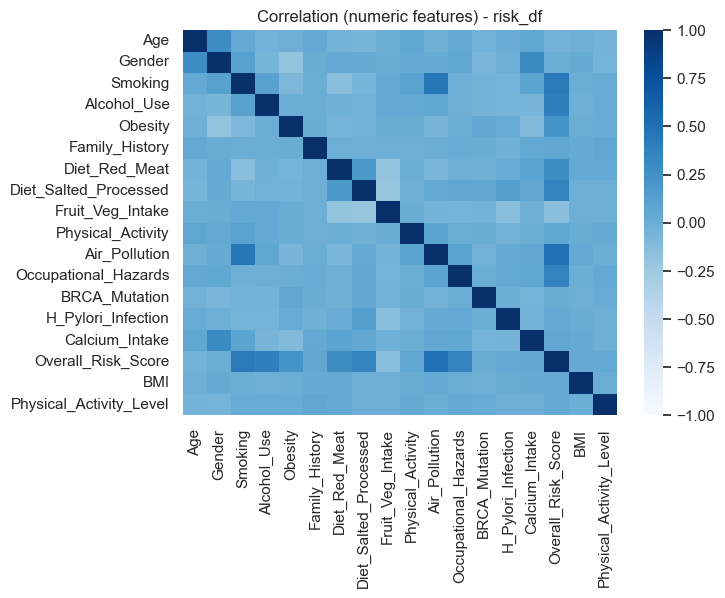

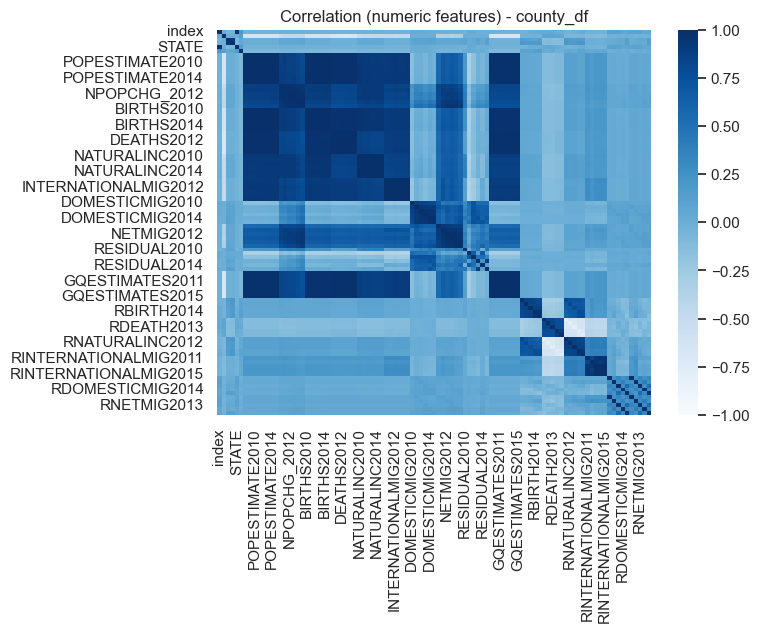

In [ ]:
# Mapa de calor de correlación (caracter. númericas)
def plot_corr(df, name):
    numeric_cols = df.select_dtypes(include="number").columns.tolist()
    if len(numeric_cols) < 2:
        raise ValueError(f"Not enough numeric columns in {name} for correlation")
    corr = df[numeric_cols].corr()
    plt.figure(figsize=(7, 5))
    sns.heatmap(corr, annot=False, cmap='Blues', vmin=-1, vmax=1)
    plt.title(f"Correlation (numeric features) - {name}")
    plt.show()

if "risk_df" in globals():
    plot_corr(risk_df, "risk_df")
elif "dataset_final" in globals():
    plot_corr(dataset_final, "dataset_final")
else:
    raise NameError("No dataset found. Run the download/load cell first.")

if "county_df" in globals():
    plot_corr(county_df, "county_df")

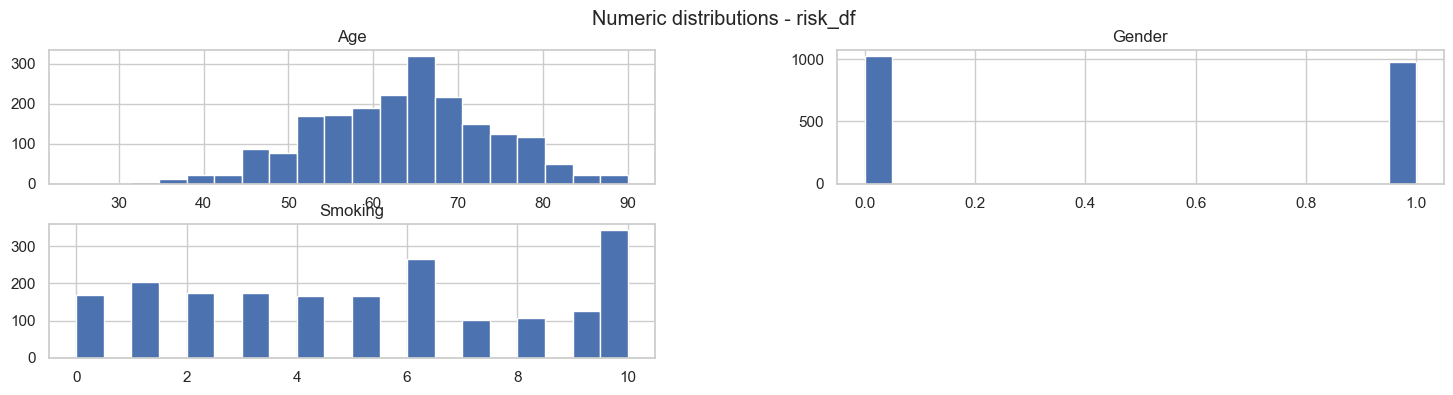

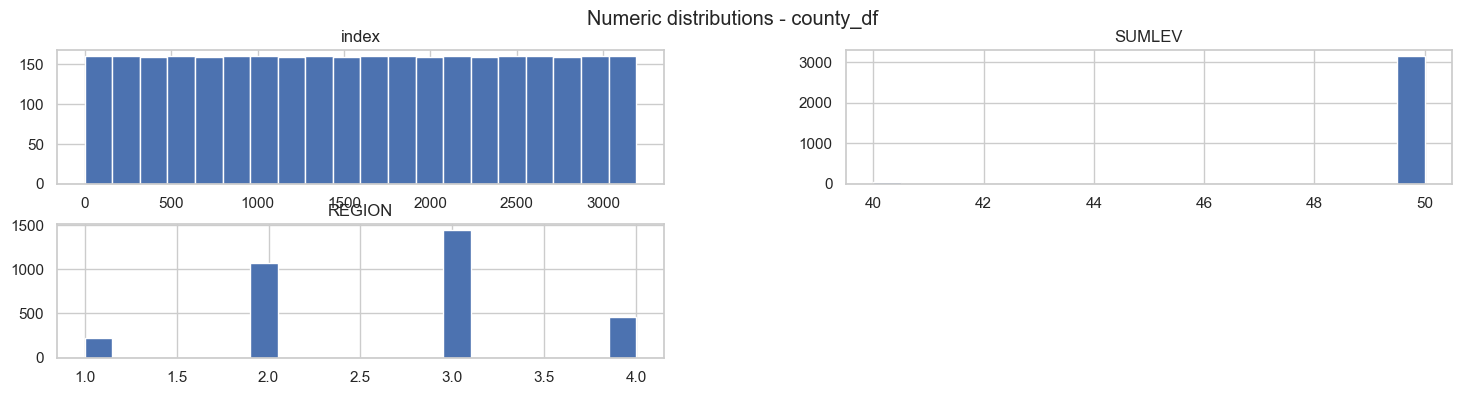

In [ ]:
# Histogramas de las primeras 3 columnas numéricas- ver distribución 
def plot_numeric_hists(df, name, max_cols=3):
    numeric_cols = df.select_dtypes(include="number").columns.tolist()
    if not numeric_cols:
        print(f"No numeric columns in {name}")
        return
    cols = numeric_cols[:max_cols]
    df[cols].hist(bins=20, figsize=(6 * len(cols), 4))
    plt.suptitle(f"Numeric distributions - {name}")
    plt.show()

for name in ("risk_df", "county_df"):
    if name in globals():
        plot_numeric_hists(globals()[name], name)

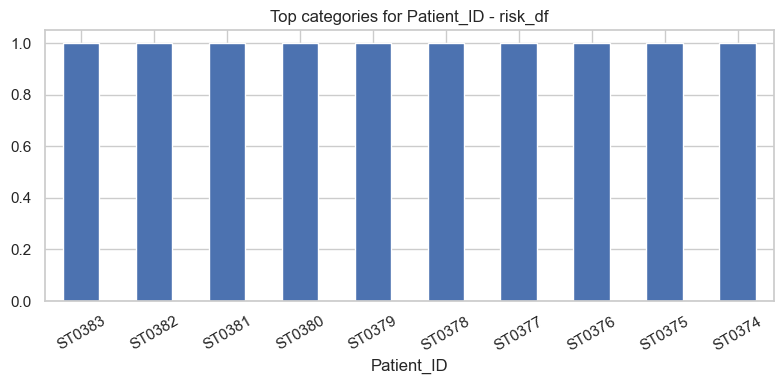

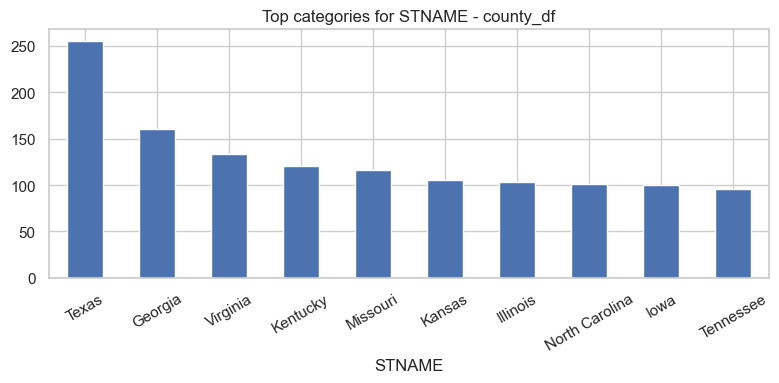

In [ ]:
# Recuento categórico
def plot_top_category(df, name):
    # Seleccionar primera columna categórica
    cat_cols = df.select_dtypes(include=["object", "category"]).columns.tolist()
    if not cat_cols:
        print(f"No categorical columns in {name}")
        return
    col = cat_cols[0]
    plt.figure(figsize=(8, 4))
    # Gráfico de barras de las 10 categorías más frecuentes
    df[col].value_counts().head(10).plot(kind="bar")
    plt.title(f"Top categories for {col} - {name}")
    plt.xticks(rotation=30)
    plt.tight_layout()
    plt.show()

for name in ("risk_df", "county_df"):
    if name in globals():
        plot_top_category(globals()[name], name)